In [1]:
import pickle

pkl_file_path = "/home/uynk/Belgeler/Analyze_Projects/AliBaba_GenAI_Dataset/dataframes.pkl"

with open(pkl_file_path, 'rb') as file:
    dataframes = pickle.load(file)

## **<span style="color:orange">Analysis:</span>** 
### **<span style="color:orange"> Bottleneck detection and Load balancing optimization of pods at specific time intervals </span>** 


### **<span style="color:orange">Feature Engineering </span>** 

**Load Balancer vulnerability analysis**: Assigning more work to pods running at low capacity during peak transaction times in the system. Workload balancing analysis.
**Cloud Cost Optimization**: The operation of pods running at low capacity during specific idle times. Analysis of whether they can be shut down when necessary.

In [3]:
import pandas as pd

# Our list of files
file_list = ["pod_gpu_duty_cycle_anon.csv",
             "pod_memory_util_anon.csv",
             "queue_rt_raw_anon.csv",
             "model_predict_data_anon.csv",
             "pipeline_inference_data_anon.csv"]

def get_global_time_range(datas):
    all_mins = []
    all_maxs = []
    
    for file in datas:
        data = dataframes[file]
        
        all_mins.append(data["real_time_CST"].min())
        all_maxs.append(data["real_time_CST"].max())
    
    global_earliest = min(all_mins)
    global_latest = max(all_maxs)
    
    print("Global Time Frame of the 4 Datasets:")
    print(f"Start Time (Lowest): {global_earliest}")
    print(f"End Time (Highest) : {global_latest}")
    
    return global_earliest, global_latest

lowest_time, highest_time = get_global_time_range(file_list)



def get_common_ips(file_names):
    ip_sets = []
    
    for file in file_names:
        unique_ips = set(dataframes[file]["container_ip"].unique())
        
        ip_sets.append(unique_ips)
        print(f"✔️ Found {len(unique_ips)} unique pods in the {file} table.")
        
    common_ips = set.intersection(*ip_sets)
    
    print(f"🎯 Number of COMMON pods found across all {len(file_names)} tables: {len(common_ips)}")
    
    return common_ips

common_pods = get_common_ips(file_list)




def combine_data_by_minute_event(datas, dataframes_dict, common_ips):
    # We create the time backbone containing the extreme boundaries
    time_series = pd.date_range(start=lowest_time, end=highest_time, freq="1min")
    df_real_time_CST = pd.DataFrame({'real_time_CST': time_series})
    
    processed_dfs = []
    
    for file in datas:
        df = dataframes_dict[file].copy()
        
        # 1. Filter the 130 common pods
        df = df[df["container_ip"].isin(common_ips)]
        
        # 2. Exactly as you said: Round the seconds to the BEGINNING of that minute (:00) and label it
        # E.g.: 09:12:05 -> becomes 09:12:00 or 09:12:40 -> becomes 09:12:00.
        df['real_time_CST'] = pd.to_datetime(df['real_time_CST']).dt.floor('1min')
        
        clean_name = file.replace(".csv", "").replace("_anon", "")
        new_col_name = f"{clean_name}_value"
        df.rename(columns={"value": new_col_name}, inplace=True)
        
        # 3. GROUPING THE VALUES WITHIN THAT MINUTE
        # In your logic: "Let the GPU peak at 09:12:05 and the predict time at 09:12:40 meet on the same 09:12:00 row"
        if "pod_gpu_duty_cycle" in clean_name or "pod_memory_util" in clean_name:
            # For resource consumption, we capture the HIGHEST (max) second within that minute
            # This way, that GPU peak at 09:12:05 is written straight to the row.
            grouped = df.groupby(['real_time_CST', 'container_ip'])[new_col_name].max().reset_index()
        else:
            # For Predict and Pipeline times, we take the average/total time of operations completed within that minute
            grouped = df.groupby(['real_time_CST', 'container_ip'])[new_col_name].mean().reset_index()
            
        processed_dfs.append(grouped)
        print(f"✔️ {file} -> Prepared according to the 1-minute pooling logic.")

    # 4. INTERSECTION (INNER JOIN)
    print("\n🔄 Merging the 4 datasets using the ['real_time_CST', 'container_ip'] key...")
    new_data = processed_dfs[0]
    
    for next_df in processed_dfs[1:]:
        # how='inner': Exactly as you said, only the common pods with a record in that MINUTE across all 4 datasets will match
        new_data = pd.merge(new_data, next_df, on=['real_time_CST', 'container_ip'], how='inner')
        
    # Chronological sorting
    new_data.sort_values(by=['container_ip', 'real_time_CST'], inplace=True)
    new_data.reset_index(drop=True, inplace=True)
    
    print("✅ The new_data dataset, working exactly with the logic you wanted, has been successfully created!")
    return new_data

new_data = combine_data_by_minute_event(file_list, dataframes, common_pods)
new_data.head()

Global Time Frame of the 4 Datasets:
Start Time (Lowest): 2022-09-11 09:12:00
End Time (Highest) : 2022-09-12 08:00:00
✔️ Found 143 unique pods in the pod_gpu_duty_cycle_anon.csv table.
✔️ Found 208 unique pods in the pod_memory_util_anon.csv table.
✔️ Found 106 unique pods in the queue_rt_raw_anon.csv table.
✔️ Found 130 unique pods in the model_predict_data_anon.csv table.
✔️ Found 132 unique pods in the pipeline_inference_data_anon.csv table.
🎯 Number of COMMON pods found across all 5 tables: 105
✔️ pod_gpu_duty_cycle_anon.csv -> Prepared according to the 1-minute pooling logic.
✔️ pod_memory_util_anon.csv -> Prepared according to the 1-minute pooling logic.
✔️ queue_rt_raw_anon.csv -> Prepared according to the 1-minute pooling logic.
✔️ model_predict_data_anon.csv -> Prepared according to the 1-minute pooling logic.
✔️ pipeline_inference_data_anon.csv -> Prepared according to the 1-minute pooling logic.

🔄 Merging the 4 datasets using the ['real_time_CST', 'container_ip'] key...
✅ 

,real_time_CST,container_ip,pod_gpu_duty_cycle_value,pod_memory_util_value,queue_rt_raw_value,model_predict_data_value,pipeline_inference_data_value
0,2022-09-11 10:31:00,00800b6d2cabe5b9ce855ec9eab6e9ff,23.933333,0.890142,352.0,38836.0,26696.0
1,2022-09-11 11:00:00,00800b6d2cabe5b9ce855ec9eab6e9ff,26.000000,0.890044,126.0,35989.0,25865.0
2,2022-09-11 11:03:00,00800b6d2cabe5b9ce855ec9eab6e9ff,24.933333,0.893323,301.0,36018.0,25780.0
3,2022-09-11 11:08:00,00800b6d2cabe5b9ce855ec9eab6e9ff,33.000000,0.893361,174.0,36959.0,26871.0
4,2022-09-11 11:23:00,00800b6d2cabe5b9ce855ec9eab6e9ff,6.400000,0.893607,182.0,35584.0,24993.0


Data for a specific pod type might be found across all datasets, for example, within the 11:26:00-12:27:00 time range. That pod might be hosting the steps and data of many different processes. A new model might just be loading into the GPU for one process, it might be in the queue, or it might be at the end of its execution process. But essentially, these are all events occurring on that pod, measured within that 1-minute time window. Within that time range, data for the average queue waiting time, maximum GPU and RAM usage, and the average inference time in that same 1-minute interval were obtained. By separating all this data into 1-minute intervals, I am collecting the container_ips that match and have values across all 4 datasets in these intervals (whether the data pertains to a single process or multiple processes doesn't concern me). I created a new dataset by taking the matching data from these 4 datasets based on their time intervals and container_ips, and extracting their average, min, or max values depending on the type of variable.

Summary: For example, in the 12:36:00 time window, model_predict, queue_rt, and GPU_duty data might have been measured for the pod 00800b6d2cabe5b9ce855ec9eab6e9ff. Within the exact same time window, another process might have been executed on the same pod, and perhaps only the model_predict time was measured. Again, in the same time window, yet another process might have been executed for the same pod, and its pipeline_inference time might have been measured. By using an inner join in our code, the average, min, and max aggregations of these different processes on the same pod and time window are calculated, reducing them down to a single row belonging to that specific time window and pod. Through this, we attempted to determine the load and usage pattern on that pod.

### **<span style="color:orange"> Outlier detections in new_data </span>** 

In [4]:
features = [
    'pod_gpu_duty_cycle_value', 
    'pod_memory_util_value', 
    'queue_rt_raw_value', 
    'model_predict_data_value', 
    'pipeline_inference_data_value'
]

def count_outliers_iqr(df, columns):
    print("🚨 VARIABLE-BASED OUTLIER REPORT 🚨")
    print("-" * 55)
    
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Filter those outside the boundaries
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_count = len(outliers)
        outlier_ratio = (outlier_count / len(df)) * 100
        
        print(f"📌 {col}:")
        print(f"   Upper Bound Value : {upper_bound:.2f}")
        print(f"   Number of Outlier Rows: {outlier_count} ({outlier_ratio:.2f}%)\n")

# Run the function
count_outliers_iqr(new_data, features)

🚨 VARIABLE-BASED OUTLIER REPORT 🚨
-------------------------------------------------------
📌 pod_gpu_duty_cycle_value:
   Upper Bound Value : 46.93
   Number of Outlier Rows: 27 (1.99%)

📌 pod_memory_util_value:
   Upper Bound Value : 1.18
   Number of Outlier Rows: 1 (0.07%)

📌 queue_rt_raw_value:
   Upper Bound Value : 476.00
   Number of Outlier Rows: 48 (3.54%)

📌 model_predict_data_value:
   Upper Bound Value : 62428.50
   Number of Outlier Rows: 249 (18.36%)

📌 pipeline_inference_data_value:
   Upper Bound Value : 42786.00
   Number of Outlier Rows: 7 (0.52%)



### **<span style="color:orange"> Model:</span>** 
#### **<span style="color:orange"> Robust Scaling & PAM Cluster </span>** - First, RobustScaler should be applied so that outliers are not suppressed (squashed), but the variable units are properly scaled. 

- The PAM algorithm randomly selects a number of rows equal to the number of clusters I specify and accepts them as medoid cluster leaders. All remaining rows in the dataset are spatially assigned to the Medoid closest to them. Generally, Manhattan (L1 Norm) and Euclidean (L2 Norm) distances are used for distance measurement. The Manhattan distance between two data points is:

$$d(x, y) = \sum_{i=1}^{n} |x_i - y_i|$$

- Swap and Cost: The algorithm asks, "If I make an ordinary row the leader instead of this leader I chose, would the total distance within the cluster decrease?". A Medoid is swapped with a non-medoid point. 

- Convergence: If the swap operation reduces the total cost, that new point becomes the new leader.

In [ ]:
# --- SYSTEM CONFIGURATION AND LIBRARIES ---
import pandas as pd
import numpy as np
import warnings

# Compatibility patch so the pyclustering library (2022) does not crash with modern NumPy:
np.warnings = warnings 

from sklearn.preprocessing import RobustScaler
from pyclustering.cluster.kmedoids import kmedoids
from pyclustering.cluster.center_initializer import kmeans_plusplus_initializer
# ----------------------------------------------
# Since the pyclustering library contains a command called numpy.warning, and this command is no longer included in numpy version 1.26.4, we patched the code to make it look like there is a warning module inside numpy so pyclustering can find it.



features = [
    'pod_gpu_duty_cycle_value', 
    'pod_memory_util_value', 
    'queue_rt_raw_value', 
    'model_predict_data_value', 
    'pipeline_inference_data_value'
]
X = new_data[features]

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X).tolist() 
print("Algorithm is running, searching for 3 main bottleneck/leader pods...")

# The first leader is chosen randomly. The second is chosen from those furthest from the first. The third is chosen from those furthest from the first two.
initial_medoids = kmeans_plusplus_initializer(X_scaled, 3, random_state=42).initialize(return_index=True) 
print(initial_medoids) # The 3 selected leaders. 

pam = kmedoids(X_scaled, initial_medoids)  
pam.process() # The distances of all other pods to these 3 leaders are calculated. If necessary, leaders are swapped, and it loops until the clusters are optimized (yielding the least error). 

# Applying Clusters to the Dataset
clusters = pam.get_clusters()

# First, we create an empty column (filled with -1) named 'Cluster' in the dataset
new_data['Cluster'] = -1 

# Using enumerate, we simultaneously get the cluster number (0, 1, 2) and the list of rows belonging to that cluster
for cluster_id, row_indices in enumerate(clusters):
    # With iloc, we go to those rows and write their respective cluster number (cluster_id) in the 'Cluster' column
    new_data.iloc[row_indices, new_data.columns.get_loc('Cluster')] = cluster_id

print("✅ PAM algorithm ran successfully and the dataset is clustered!")

# Let's clearly see the cluster distributions on the screen
display(new_data['Cluster'].value_counts())

Algorithm is running, searching for 3 main bottleneck/leader pods...
[1309, 1004, 185]
✅ PAM algorithm ran successfully and the dataset is clustered!


Cluster
2    924
0    243
1    189
Name: count, dtype: int64

In [6]:
# Calculate the average values of those 5 metrics for each cluster
cluster_profiles = new_data.groupby('Cluster')[features].mean()
display(cluster_profiles.T)

Cluster,0,1,2
pod_gpu_duty_cycle_value,26.539672,12.606702,25.360299
pod_memory_util_value,0.670654,0.661335,0.662288
queue_rt_raw_value,261.013374,248.427249,228.142587
model_predict_data_value,63616.514403,13578.825397,37554.477814
pipeline_inference_data_value,24245.953018,10911.558642,23486.470869


- 🔴 **Cluster 0 Bottleneck (Pods Crushed Under Heavy Load):** This cluster may represent pods experiencing an overload that pushes the limits of the system. Due to heavy processing volumes, it likely contains the time intervals and `container_ip`s where queue waiting times and latencies are at their peak.
- 🔵 **Cluster 1 Idle Capacity (Pods Waiting in Idle):** This cluster might represent pods that are not receiving a sufficient workload despite having their resources reserved. They may exhibit low processing volumes and low GPU usage.
- 🟢 **Cluster 2 Ideal Performance (Healthy Worker Pods):** This cluster reflects the targeted optimum operating state within the cloud infrastructure. They are likely receiving balanced workloads appropriate for their capacities, allowing them to utilize GPU resources efficiently.

### **<span style="color:orange"> EDA - Timeline Graph of Number of Operations by Set - </span>**

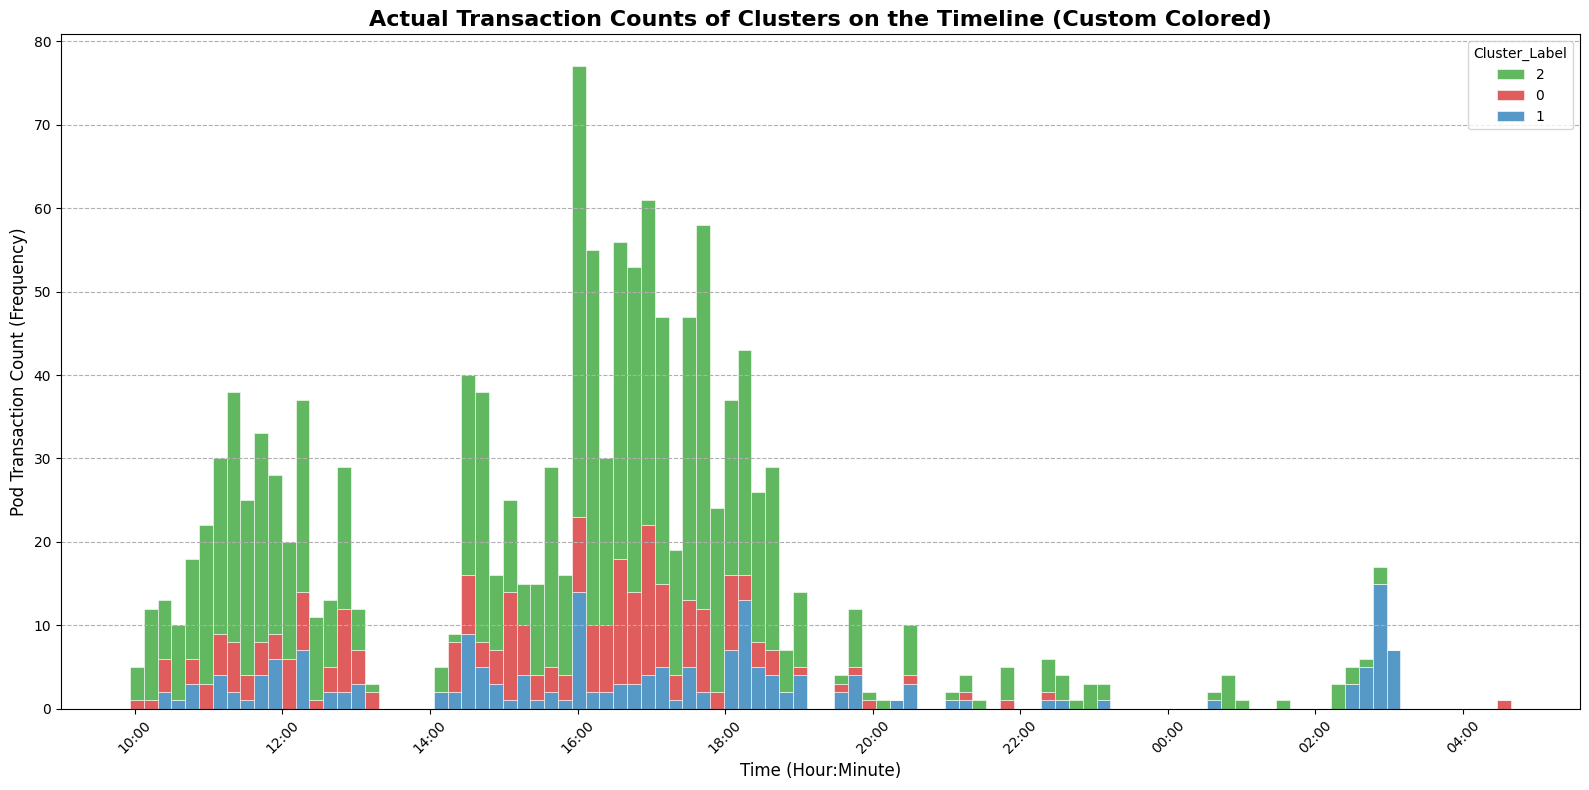

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# 1. Data format preparation (Same as before)
new_data["Cluster_Label"] = new_data["Cluster"].astype(str)

# 2. CUSTOM COLOR PALETTE DICTIONARY (Here is the magic)
# To avoid overly bright/harsh colors, we use matplotlib's professional "tab:" colors
custom_colors = {
    "0": "tab:red",    # Cluster 0 (Bottleneck) -> Red
    "1": "tab:blue",   # Cluster 1 (Idle)       -> Blue
    "2": "tab:green"   # Cluster 2 (Healthy)    -> Green
}

plt.figure(figsize=(16, 8))

# 3. Plotting the Graph
ax = sns.histplot(
    data=new_data, 
    x="real_time_CST", 
    hue="Cluster_Label", 
    multiple="stack",   
    bins=100,            
    palette=custom_colors, 
    edgecolor="white",
    linewidth=0.4
)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.title("Actual Transaction Counts of Clusters on the Timeline (Custom Colored)", fontsize=16, fontweight='bold')
plt.xlabel("Time (Hour:Minute)", fontsize=12)
plt.ylabel("Pod Transaction Count (Frequency)", fontsize=12)

plt.xticks(rotation=45) 
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

**Interpretation of the 18-hour time frame graph:** Focusing on the blue areas, the issue of some pods remaining idle during peak transaction hours immediately stands out. We can conclude that the Internal Load Balancer might need optimization during high-traffic periods.

- The system's current load routing algorithm could be modified. Kubernetes and the Internal Load Balancer may need to check the `queue_rt_raw_value` and GPU usage metrics before dispatching a new job. `Expected outcome:` Workloads directed to the red pods should be shifted to the idle blue pods during those peak hours. This would help turn the red layer green (healthy).

- The background processes causing that inexplicably idle "blue tower" around 02:30 AM must be identified and optimized. Furthermore, it should be investigated whether pods waiting idly during non-traffic hours can be shut down (scaled to zero).